# TP4 -  Word Embeddings  (07/04/2025)

## 1 Goal

### 1.1 Word2Vec Model

<font size="3">

In this exercise we learn about the Word2Vec models. We start with the idea of training a simple neural network with one hidden layer to perform a certain task. To train the neural network, we select a specific word in the middle of a sentence (the input word), then we look at the words nearby and pick one randomly. The trained neural network tells us the probability for every word in our vocabulary of being the nearby word that we chose. The output probability is related to how likely each vocabulary word is nearby our input word. To do so, we train the neural network by feeding it word pairs found in our training documents. The below example shows some of the training samples that we would take from our dataset. Let's consider the sentence "The quick brown fox jumps over the lazy dog." as an example of the dataset. We first form a dataset of words and the contexts in which they appear. We could define context in any way that makes sense, for example, words-to-the-left of the target, words-to-the-right of the target. Using a window size of $1\: (m=1)$, we then have the dataset:<br> (<b>[the, brown], quick), ([quick, fox], brown), ([brown, jumped], fox),...</b> of (context, target)  pairs. In the Skip-Gram model, we attempt to predict the context words from its target word, so the task becomes to predict 'the' and 'brown' from 'quick', 'quick' and 'fox' from 'brown', etc. Therefore our dataset becomes <b>D: (quick, the), (quick, brown), (brown, quick), (brown, fox),...</b>
of (input, output) pairs.
    
However, we can not feed the neural network words as a text string, so we need find a numerical representation of words. To do this, we select a vocabulary of words $V$ from our training documents, e.g., 10000 unique words $(|V|=10000)$. Then, we represent each input word as a one-hot vector (one-hot encoding). Each vector would have 10000 elements (one for every word in our vocabulary) in which "1" is placed in the position corresponding to the given word and and "0" in all of the other positions. The output of the network is a single vector also with 10,000 components for every word in our vocabulary.

We train our network to compute $P(context|target)$. Let us denote
the input by x (target word), the output by c (context word), and  $h_x$ and $h_c$ as the representation (embedding) of the
target and context word. The representation is computed by:

$$ h_x = Wx$$
$$h_c = W'c$$

where $W$ and $W'$ are matrices of dimension (Embedding size $\times$ Vocabulary size) and the learnable parameters of the model. The probability model is then
given by:

$$P(c|x) = \frac{\exp(h_c \cdot h_x)}{\sum_i\exp(h_i \cdot h_x)}$$

Our goal is to maximize the average likelihood on the whole corpus. The likelihood is defined as:

\begin{align*}
L &= \lambda\sum_{x}\log(P(c-m, \ldots, c-1, c+1, \dots c+m | x)) \\
   &=  \lambda\sum_{x}\log(\prod_{j=0, j \neq m}^{2m}P(c-m+j | x)) \\
   &= \lambda\sum_{x}\sum_{j=0, j \neq m}^{2m} \log P(c-m+j | x)) \\
   &=  \lambda\sum_{(c,x) \in \texttt{D} }\log P(c | x)
\end{align*}

The training is done using stochastic gradient descent (SGD) or mini-batch SGD. After training, the embeddings can be extracted from the $W$ and $W'$ matrices as $e_x = Wx$ or $e_x = (W + W')x/2$
</font>

### 1.2 Negative Sampling

<font size="3">

Evaluating the denominator in the expression of $P(c|x)$ for each training step is very costly as we need to evaluate it for each word in the vocabulary. This will update all rows of $E'$ at every step by simultaneously making the embedding for x closer to c and further from all other terms $c'\neq c, c'\in V$ together. This is a characteristic of the softmax function. Negative sampling is an approximation to the above optimization problem (or any multi-class classification problem) where at each step, we only update one row of the classifier $E'$ (corresponding to c). The probability model is modified as:<br>
    $$P(c|x) = \sigma(h_c \cdot h_x)=\frac{1}{1+exp(-h_c \cdot h_x)}$$
where $\sigma(.)$ is the sigmoid function. The goal would be to predict high probabilities $(=1)$ for $(c, t) \in D$. This essentially brings the embedding for x closer to c but does not push it away from the other words in the vocabulary. Thus we need to add negative samples to enforce that. For each target word, we sample a fixed number n of negative examples uniformly from the vocabulary (excluding the target word itself). Let's consider the previous example: "The quick brown fox jumps over the lazy dog." Using a window size of 1, we got the dataset: (<b>[the, brown], quick), ([quick, fox], brown), ([brown, jumped], fox,...</b>) of (context, target) pairs. The negative examples for <b>quick</b> after sampling from the whole vocabulary could be <b>[jumps, lazy]</b>. Further we can attach labels 1 for positive examples and 0 for negative examples, i.e., we want to predict high probability values for positive examples and low probability values for negative examples and get the following dataset: <b>D: ((quick, the),1), ((quick, brown), 1), ((quick, jumps), 0), ((quick, lazy), 0), ((brown, quick), 1), ((brown, fox), 1)...</b>
    
We can rewrite the probability model to also include the labels as:<br>
    $$P(y=1|(c,x)) = \sigma(h_c \cdot h_x)=\frac{1}{1+exp(-h_i \cdot h_x)}$$
    
The likelihood can then be written as
    
\begin{align*}
L &= \lambda\sum_{((x,c),y) \in D}\log P(y | (c,x)) \\
   &=  \lambda\sum_{((x,c),y) \in D}y\log P(y | (c,x)) + (1-y)\log(1-P(y | (c,x)))
\end{align*}
    
which is the familiar cross entropy loss function used for binary classification.
    
</font>

## 2. List of tasks

<font size="3">
Before implementing the next tasks, follow these two tutorials on <a href="https://colab.research.google.com/drive/1258rEE8l0hXin2_DSbg77RvAgXYKi508?usp=sharing" target="_blank">PyTorch</a> and <a href="https://colab.research.google.com/drive/1d1Xkw8zsuqO67fuadPIi59hIr-grnuu9?usp=sharing" target="_blank">Word Embeddings</a> for more examples on Neural Networks with PyTorch, models of Continuous Bag-of-words, Skip-Gram and Negative Sampling.
</font>

### 2.1 Skip-Gram Model

<font size="3">
Choose one or more French books as your corpus from the <a href="http://www.gutenberg.org/" target="_blank">project Guttenberg web site</a>, for example  
        <ul>
            <li><a href="http://www.gutenberg.org/ebooks/5097" target="_blank">20000 Lieues Sous Les Mers</a></li>
            <li><a href="http://www.gutenberg.org/ebooks/13951" target="_blank">Les Trois Mousquetaires</a></li>
            <li><a href="http://www.gutenberg.org/ebooks/5423" target="_blank">L'homme Qui Rit</a></li>
            <li><a href="http://www.gutenberg.org/ebooks/14286" target="_blank">L'Odyssée</a></li>
            <li><a href="http://www.gutenberg.org/ebooks/9945" target="_blank">Histoire de la Révolution française</a></li>
    </ul>
<ol>
    <li>Generate a dataset of word pairs by means of a window size of 2 (two words-to-the-left of the target, two words-to-the-right of the target).</li>
    <li>Train a neural network on this dataset using the Skip-Gram model. You can use PyTorch or TensorFlow.</li>
    <li>Plot the training curve (likelihood/epoch) and give the running time per epoch.</li>
    <li>If possible give the running time per epoch on GPU and compare with respect to a CPU.</li>
    <li>Find 5 most likely nearby words of 10 extremely frequent words in your corpus (TP3, task 2.2.3) and summarize them in a   table.</li>
    </ol>    
</font>

### 2.2 Negative Sampling

<font size="3">
    <ol>
    <li>Train another neural network on the same dataset with negative sampling.</li>
    <li>Plot the training curve and compare it with the above model.</li>
    <li>Find 5 most likely nearby words of 10 extremely frequent words, as before.</li>
    </ol>
</font>

## 3 Assessment

<font size="3">
    
Please save your notebook as "TP4_NameSurname.ipynb" and upload it to <a href="http://moodle.unige.ch" target="_blank">Moodle</a> in the section <b>Submissions 2025</b> under TP4 before Sunday, April 27, 2025, 23:59.
Later submissions will not be accepted.
    
</font>

In [ ]:
from collections import Counter
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

import time
import torch
import torch.nn.functional as F
from torch.nn import Module, Embedding, Linear, CrossEntropyLoss
from torch.nn.functional import softmax
from torch.optim import SGD, Adam
from torch.utils.data import Dataset, DataLoader

drive.mount('/content/drive')

Mounted at /content/drive


## 2.1 Skip-Gram Model
### Choose one or more French books as your corpus from the project Guttenberg web site

We choosed ***Les Trois Mousquetaires***

1. Generate a dataset of word pairs by means of a window size of 2 (two words-to-the-left of the target, two words-to-the-right of the target).

In [ ]:
with open("/content/drive/MyDrive/Colab Notebooks/3_mousquetaires.txt", 'r') as f:
        text_data = f.read()

In [ ]:
def preprocess_raw_text(text):
  # text should be a string, returns a list of tags
  text = text.lower()
  text = re.sub(r'[^\w\s]', '', text).split() #because in french we have a lot of apostrophe, hyphen...

  return text

tokens = preprocess_raw_text(text_data)

In [ ]:
def generate_dataset(text, window_size=2):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text).split()
    # words = text.replace('.', '').replace(',', '').split()

    pairs = []

    for i, target_word in enumerate(text):
        # Define the window range
        for j in range(i - window_size, i + window_size + 1):
            if j != i and 0 <= j < len(text):
                context_word = text[j]
                pairs.append((target_word, context_word))

    return pairs

dataset = generate_dataset(text_data, window_size=2)
dataset

[('the', 'project'),
 ('the', 'gutenberg'),
 ('project', 'the'),
 ('project', 'gutenberg'),
 ('project', 'ebook'),
 ('gutenberg', 'the'),
 ('gutenberg', 'project'),
 ('gutenberg', 'ebook'),
 ('gutenberg', 'of'),
 ('ebook', 'project'),
 ('ebook', 'gutenberg'),
 ('ebook', 'of'),
 ('ebook', 'les'),
 ('of', 'gutenberg'),
 ('of', 'ebook'),
 ('of', 'les'),
 ('of', 'trois'),
 ('les', 'ebook'),
 ('les', 'of'),
 ('les', 'trois'),
 ('les', 'mousquetaires'),
 ('trois', 'of'),
 ('trois', 'les'),
 ('trois', 'mousquetaires'),
 ('trois', 'this'),
 ('mousquetaires', 'les'),
 ('mousquetaires', 'trois'),
 ('mousquetaires', 'this'),
 ('mousquetaires', 'ebook'),
 ('this', 'trois'),
 ('this', 'mousquetaires'),
 ('this', 'ebook'),
 ('this', 'is'),
 ('ebook', 'mousquetaires'),
 ('ebook', 'this'),
 ('ebook', 'is'),
 ('ebook', 'for'),
 ('is', 'this'),
 ('is', 'ebook'),
 ('is', 'for'),
 ('is', 'the'),
 ('for', 'ebook'),
 ('for', 'is'),
 ('for', 'the'),
 ('for', 'use'),
 ('the', 'is'),
 ('the', 'for'),
 ('the', 

#### Vocabulary and Indexing

In [ ]:
counts = Counter(tokens)

In [ ]:

counts.most_common(10)

[('de', 8984),
 ('et', 5803),
 ('la', 5408),
 ('le', 5163),
 ('à', 4717),
 ('que', 3808),
 ('vous', 3513),
 ('je', 2667),
 ('il', 2569),
 ('les', 2513)]

In [ ]:
def build_vocab(tokens, max_vocab_size=None):
  counts = Counter(tokens)

  if max_vocab_size is None:
    max_vocab_size = 0

  to_keep = counts.most_common(max(max_vocab_size, len(counts)))

  word2id = {}
  index = 1  # start indexing from 1
  word2id['<pad>'] = 0  # add a padding token

  for token, count in to_keep:
      word2id[token] = index
      index += 1

  id2word = list(word2id.keys())

  return word2id, id2word

In [ ]:
word2id, id2word = build_vocab(tokens)

In [ ]:
id2word[0], id2word[1], word2id['and'], word2id['the']

('<pad>', 'de', 397, 146)

In [ ]:
word2id,

({'<pad>': 0,
  'de': 1,
  'et': 2,
  'la': 3,
  'le': 4,
  'à': 5,
  'que': 6,
  'vous': 7,
  'je': 8,
  'il': 9,
  'les': 10,
  'un': 11,
  'en': 12,
  'qui': 13,
  'pas': 14,
  'dartagnan': 15,
  'ne': 16,
  'ce': 17,
  'dit': 18,
  'une': 19,
  'son': 20,
  'dans': 21,
  'se': 22,
  'mais': 23,
  'pour': 24,
  'lui': 25,
  'du': 26,
  'au': 27,
  'des': 28,
  'était': 29,
  'sur': 30,
  'cette': 31,
  'avait': 32,
  'comme': 33,
  'sa': 34,
  'plus': 35,
  'quil': 36,
  'nous': 37,
  'avec': 38,
  'bien': 39,
  'tout': 40,
  'me': 41,
  'elle': 42,
  'si': 43,
  'athos': 44,
  'mon': 45,
  'par': 46,
  'cest': 47,
  'est': 48,
  'ses': 49,
  'milady': 50,
  'a': 51,
  'm': 52,
  'votre': 53,
  'on': 54,
  'deux': 55,
  'porthos': 56,
  'moi': 57,
  'monsieur': 58,
  'donc': 59,
  'cardinal': 60,
  'sans': 61,
  'homme': 62,
  'fait': 63,
  'aramis': 64,
  'ma': 65,
  'femme': 66,
  'faire': 67,
  'dun': 68,
  'cela': 69,
  'où': 70,
  'oui': 71,
  'ou': 72,
  'jeune': 73,
  'même':

In [ ]:
vocab_size = len(word2id)
vocab_size

16678

#### Vectorizing and One-hot

In [ ]:
def vectorize_tokens(tokens, word2id):
  # tokens is a list of words
  return [word2id[word] for word in tokens]

In [ ]:
tokens_vector = vectorize_tokens(tokens, word2id)

In [ ]:
from torch.nn.functional import one_hot
import torch

def get_one_hot(tokens_vector, num_classes=-1):
  tokens_vector = torch.tensor(tokens_vector)
  return one_hot(tokens_vector, num_classes)

In [ ]:
len(tokens_vector)

223483

In [ ]:
get_one_hot(tokens_vector).shape

torch.Size([223483, 16678])

### 2. Train a neural network on this dataset using the Skip-Gram model. You can use PyTorch or TensorFlow

In [ ]:
class SkipGramDataset(Dataset):
  def __init__(self, ws=2, one_hot=False, flatten_examples=True, filepath='/content/drive/MyDrive/Colab Notebooks/3_mousquetaires.txt'):
    super(SkipGramDataset, self).__init__()

    self.ws = ws
    self.one_hot = one_hot
    self.flatten_examples = flatten_examples

    if self.flatten_examples:
        self.skipgram_pairs = self.skipgram_pairs_v1
    else:
        self.skipgram_pairs = self.skipgram_pairs_v2

    # Load and preprocess sentences from file
    with open(filepath, 'r') as f:
        text = f.read().lower()

    # Basic sentence splitting (you could replace this with nltk.sent_tokenize or similar)
    import re
    sentences = [sentence.strip() for sentence in re.split(r'[.?!\n]', text) if sentence.strip()]

    # Tokenize each sentence
    sentences_tokens = [preprocess_raw_text(sentence) for sentence in sentences]

    # Flatten all tokens for vocab building
    tokens_flattened = [token for sentence in sentences_tokens for token in sentence]

    # Build vocab and convert tokens to IDs
    self.word2id, self.id2word = build_vocab(tokens_flattened)
    self.vocab_size = len(self.word2id)

    self.sentences_tokens_id = [vectorize_tokens(sentence_tokens, self.word2id) for sentence_tokens in sentences_tokens]

    # Generate skip-gram pairs
    self.train_data = self.skipgram_pairs(self.sentences_tokens_id, self.ws)


  def __len__(self):
    return len(self.train_data)

  def __getitem__(self, idx):
    target = self.train_data[idx][0]
    context = self.train_data[idx][1]

    if self.one_hot:
      context = get_one_hot(context, self.vocab_size)
      target = get_one_hot(target, self.vocab_size)
    else:
      context = torch.tensor(context, dtype=torch.long)
      target = torch.tensor(target, dtype=torch.long)


    return target, context #, 1


  def skipgram_pairs_v1(self, sentences_tokens, ws):
    train_data = []
    for sentence_tokens in sentences_tokens:
      for token_idx, target in enumerate(sentence_tokens):
        for idx in range(max(0,token_idx-ws), min(token_idx+ws+1, len(sentence_tokens))):
          if idx == token_idx:
            continue

          train_data.append((target, sentence_tokens[idx], 1))
        # negative sampling
        # [0, 1, 2, 3, 4.., |V|-1]
        # append negative samples to train_data : label => 0 (target, negative_sample, )
        # (3, 1, label=1); (3, 5, label=1); (3, ..)
    return train_data

  def skipgram_pairs_v2(self, sentences_tokens, ws):

    train_data = []
    for sentence_tokens in sentences_tokens:
      for token_idx, target in enumerate(sentence_tokens):
        context = []

        for idx in range(max(0,token_idx-ws), min(token_idx+ws+1, len(sentence_tokens))):
          if idx == token_idx:
            continue

          context.append(sentence_tokens[idx])

        #train_data.append((context,target))
        train_data.append((target,context))

    return train_data

In [ ]:
skipgram_dataset = SkipGramDataset(flatten_examples=False)
skipgram_dataset.train_data

[(146, [303, 274]),
 (303, [146, 274, 1569]),
 (274, [146, 303, 1569, 222]),
 (1569, [303, 274, 222, 10]),
 (222, [274, 1569, 10, 90]),
 (10, [1569, 222, 90, 137]),
 (90, [222, 10, 137]),
 (137, [10, 90]),
 (558, [1569, 1006]),
 (1569, [558, 1006, 856]),
 (1006, [558, 1569, 856, 146]),
 (856, [1569, 1006, 146, 1570]),
 (146, [1006, 856, 1570, 222]),
 (1570, [856, 146, 222, 3239]),
 (222, [146, 1570, 3239, 5888]),
 (3239, [1570, 222, 5888, 406]),
 (5888, [222, 3239, 406, 146]),
 (406, [3239, 5888, 146, 1394]),
 (146, [5888, 406, 1394, 1092]),
 (1394, [406, 146, 1092, 397]),
 (1092, [146, 1394, 397]),
 (397, [1394, 1092]),
 (2821, [1250, 4560]),
 (1250, [2821, 4560, 222]),
 (4560, [2821, 1250, 222, 146]),
 (222, [1250, 4560, 146, 5889]),
 (146, [4560, 222, 5889, 1571]),
 (5889, [222, 146, 1571, 1922]),
 (1571, [146, 5889, 1922, 4561]),
 (1922, [5889, 1571, 4561, 397]),
 (4561, [1571, 1922, 397, 539]),
 (397, [1922, 4561, 539, 5890]),
 (539, [4561, 397, 5890, 1922]),
 (5890, [397, 539, 19

In [ ]:
# print(skipgram_dataset.sentences_tokens_id, end=' ')
skipgram_dataset.vocab_size, len(skipgram_dataset), skipgram_dataset[0], skipgram_dataset[1], skipgram_dataset[2], skipgram_dataset[3], skipgram_dataset[4]

(16665,
 223597,
 (tensor(146), tensor([303, 274])),
 (tensor(303), tensor([ 146,  274, 1569])),
 (tensor(274), tensor([ 146,  303, 1569,  222])),
 (tensor(1569), tensor([303, 274, 222,  10])),
 (tensor(222), tensor([ 274, 1569,   10,   90])))

In [ ]:
class Word2VecSkipGram(Module):

  def __init__(self, vocab_size, emb_dim):
    super(Word2VecSkipGram, self).__init__()

    self.vocab_size = vocab_size
    self.emb_dim = emb_dim

    self.embeds = Embedding(num_embeddings=self.vocab_size, embedding_dim=self.emb_dim, padding_idx=0)
    self.classif = Linear(self.emb_dim, self.vocab_size, bias=False)

  def forward(self, batch):

    context, target = batch
    # shape context : batch_size
    # shape target : batch_size

    target_embed = self.embeds(target) # shape : batch_size x  emb_dim
    logits = self.classif(target_embed) # shape : batch_size x vocab_size
    # context_embed = self.classif(target_embed) # shape : batch_size x vocab_size

    # probs = softmax(logits)

    return logits


In [ ]:
def pad_tensor(vec, pad, dim, pad_val):

    """
    args:
        vec - tensor to pad
        pad - the size to pad to
        dim - dimension to pad
        pad_val - scalar to use for padding

    return:
        a new tensor padded to 'pad' in dimension 'dim'
    """
    pad_size = list(vec.shape) # (3)
    pad_size[dim] = pad - vec.size(dim) # 4 - 3 = 1 (1, 20)
    return torch.cat([vec, torch.empty(*pad_size, dtype=vec.dtype).fill_(pad_val)], dim=dim)


class PadCollate:
    """
    a variant of callate_fn that pads according to the longest sequence in
    a batch of sequences
    """

    def __init__(self, dim=0, pad_val=0):
        """
        args:
            dim - the dimension to be padded (dimension of time in sequences)
        """
        self.dim = dim
        self.pad_val = pad_val

    def pad_collate(self, batch):
        """
        args:
            batch - list of (tensor, label)

        reutrn:
            xs - a tensor of all examples in 'batch' after padding
            ys - a LongTensor of all labels in batch
        """
        num_items = len(batch[0])
        batch = [[data_p[idx] for data_p in batch] for idx in range(num_items)] # [(1, 'a', 3.0), (5, 'd', 3.2)]  => ([(1,5], ['a', 'd'], [3.0, 3.2])

        for item_idx in range(len(batch)):
          if batch[item_idx][0].dim() == 0:
            batch[item_idx] = torch.stack(batch[item_idx], dim=0)
            continue

          # find longest sequence
          max_len = max(map(lambda x: x.shape[self.dim], batch[item_idx]))
          # pad according to max_len
          batch[item_idx] = [pad_tensor(x, pad=max_len, dim=self.dim, pad_val=self.pad_val) for x in batch[item_idx]]
          batch[item_idx] = torch.stack(batch[item_idx], dim=0)

        return tuple(batch)

    def __call__(self, batch):
        return self.pad_collate(batch)

In [ ]:
# Data
train_dataset = SkipGramDataset(ws=1, flatten_examples=True)
train_loader = DataLoader(train_dataset, batch_size=100)

# Model
emb_dim = 30
skipgramModel = Word2VecSkipGram(vocab_size=train_dataset.vocab_size, emb_dim=emb_dim)

# Optimizer
optimizer = SGD(skipgramModel.parameters(), lr=0.01)

# Loss
cross_entropy_loss = CrossEntropyLoss()

# Hyper-params
num_epochs = 50

# Metrics
losses_epoch_train = []
acc_epoch_train = []
epoch_times = []

# Training loop
for epoch in range(num_epochs):
    start_time = time.time()

    skipgramModel.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        x, y = batch
        y_scores = skipgramModel(batch)

        loss = cross_entropy_loss(y_scores, y)
        epoch_loss += loss.item()

        total += x.shape[0]
        correct_pred = torch.max(y_scores, dim=1)[1] == y
        correct += correct_pred.sum().item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    end_time = time.time()
    elapsed = end_time - start_time
    epoch_times.append(elapsed)

    losses_epoch_train.append(epoch_loss)
    accuracy = correct / total
    acc_epoch_train.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")


Epoch 1/50, Loss: 28155.4524, Accuracy: 0.3178, Time: 22.94s
Epoch 2/50, Loss: 20515.5203, Accuracy: 0.4651, Time: 22.51s
Epoch 3/50, Loss: 18230.0105, Accuracy: 0.5067, Time: 23.13s
Epoch 4/50, Loss: 16871.2758, Accuracy: 0.5340, Time: 23.08s
Epoch 5/50, Loss: 15892.4300, Accuracy: 0.5575, Time: 22.58s
Epoch 6/50, Loss: 15104.8817, Accuracy: 0.5819, Time: 22.93s
Epoch 7/50, Loss: 14439.8951, Accuracy: 0.6019, Time: 23.23s
Epoch 8/50, Loss: 13869.6113, Accuracy: 0.6138, Time: 23.24s
Epoch 9/50, Loss: 13375.4528, Accuracy: 0.6238, Time: 23.19s
Epoch 10/50, Loss: 12944.2616, Accuracy: 0.6354, Time: 22.68s
Epoch 11/50, Loss: 12563.9518, Accuracy: 0.6464, Time: 23.05s
Epoch 12/50, Loss: 12223.4476, Accuracy: 0.6556, Time: 23.25s
Epoch 13/50, Loss: 11914.1176, Accuracy: 0.6633, Time: 22.89s
Epoch 14/50, Loss: 11630.1291, Accuracy: 0.6690, Time: 23.10s
Epoch 15/50, Loss: 11367.5133, Accuracy: 0.6760, Time: 23.55s
Epoch 16/50, Loss: 11123.3745, Accuracy: 0.6841, Time: 23.56s
Epoch 17/50, Loss

3. Plot the training curve (likelihood/epoch) and give the running time per epoch.


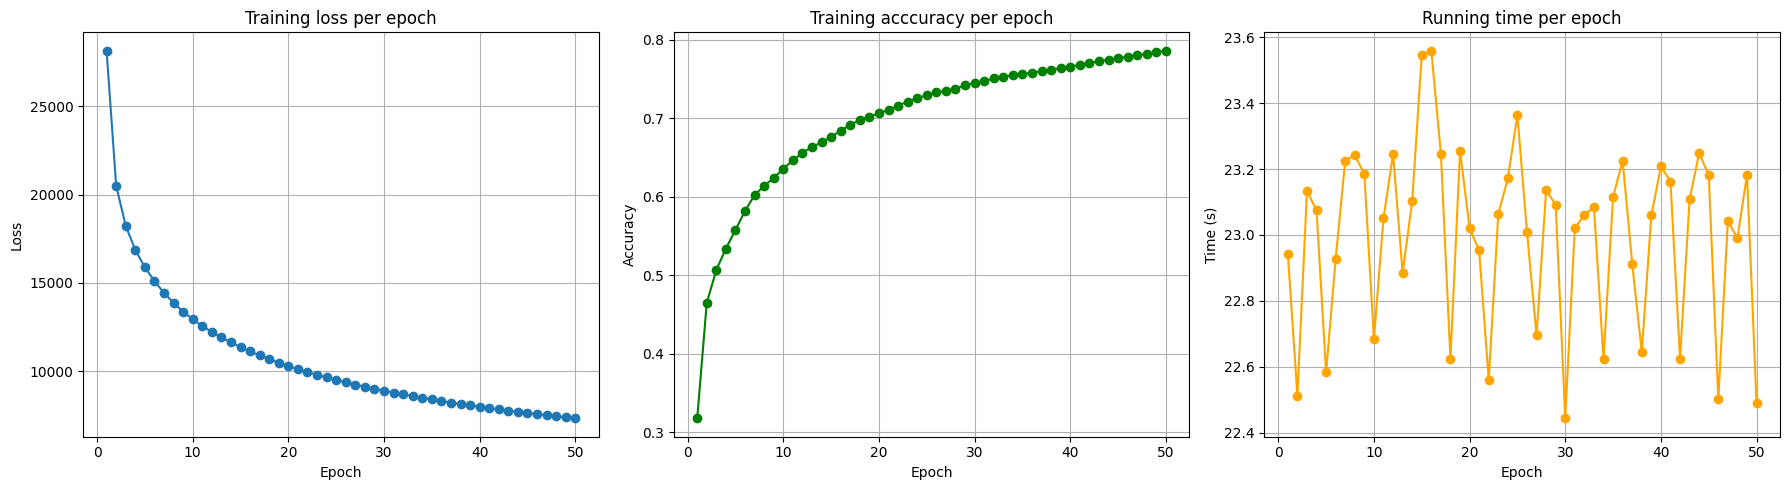

In [ ]:
# Plotting
plt.figure(figsize=(18, 5))

# Loss curve
plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), losses_epoch_train, marker='o')
plt.title("Training loss per epoch")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy curve
plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), acc_epoch_train, marker='o', color='green')
plt.title("Training acccuracy per epoch")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Time curve
plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), epoch_times, marker='o', color='orange')
plt.title("Running time per epoch")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Time (s)")

plt.tight_layout()
plt.show()


5. Find 5 most likely nearby words of 10 extremely frequent words in your corpus (TP3, task 2.2.3) and summarize them in a table.

In [ ]:
def extract_unique_words(file_path):
    unique_words = set()

    # RE to match valid words
    word_pattern = re.compile(r"\b[a-zA-Z'-]+\b")

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            #find all valid words in the line
            words = word_pattern.findall(line)
            # words to lowercase for case insensitivity
            unique_words.update(word.lower() for word in words)

    return unique_words

# get the unique words from the file
unique_words = extract_unique_words("/content/drive/MyDrive/Colab Notebooks/3_mousquetaires.txt")

print(f"Number of unique words: {len(unique_words)}")

Number of unique words: 10727


In [ ]:
def count_word_frequencies_from_list(unique_words, file_path):
    word_counter = Counter()

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            # Tokenize the line and convert to lowercase
            words = line.lower().split()
            #count only the words present in the unique_words set
            filtered_words = [word for word in words if word in unique_words]
            word_counter.update(filtered_words)

    # Sort words by frequency (descending)
    ranked_words = sorted(word_counter.items(), key=lambda x: (-x[1], x[0]))

    return ranked_words

file_path = "/content/drive/MyDrive/Colab Notebooks/3_mousquetaires.txt"

#count word frequencies from the list of unique words
ranked_words = count_word_frequencies_from_list(unique_words, file_path)

# Display the top 10 ranked words
print("Top 10 ranked words:")
for rank, (word, freq) in enumerate(ranked_words[:10], start=1):
    print(f"{rank}. {word}: {freq} occurrences")

Top 10 ranked words:
1. de: 8973 occurrences
2. et: 5577 occurrences
3. la: 5344 occurrences
4. le: 5152 occurrences
5. que: 3680 occurrences
6. vous: 3168 occurrences
7. je: 2604 occurrences
8. il: 2534 occurrences
9. les: 2508 occurrences
10. un: 2408 occurrences


In [ ]:
# ranked_words[:10]
top_10_most_frequent_words = [i[0] for i in ranked_words[:10]]
top_10_most_frequent_words

['de', 'et', 'la', 'le', 'que', 'vous', 'je', 'il', 'les', 'un']

In [ ]:
import torch

def get_predicted_context_words(model, word_indices, id2word, topn=5):
    model.eval()
    context_predictions = {}
    with torch.no_grad():
        for idx in word_indices:
            input_tensor = torch.tensor([idx])  # batch of size 1
            logits = model((input_tensor, input_tensor))  # context, target (target is used in forward)
            # logits shape: [1, vocab_size]
            top_indices = logits[0].topk(topn).indices.tolist()
            context_predictions[id2word[idx]] = [id2word[i] for i in top_indices]
    return context_predictions

# Convert words to indices
top_10_indices = [train_dataset.word2id[w] for w in top_10_most_frequent_words]

# Get predicted context words
predicted_contexts = get_predicted_context_words(skipgramModel, top_10_indices, train_dataset.id2word, topn=5)

# Display as table
import pandas as pd
df = pd.DataFrame([
    {"Target Word": k, "Top 5 nearby words": ", ".join(v)}
    for k, v in predicted_contexts.items()
])
df


,Target Word,Top 5 nearby words
0,de,"de, navait, savait, on, maintenant"
1,et,"et, savez, crois, tout, sarrêta"
2,la,"la, répondit, jusquà, aller, coup"
3,le,"le, rien, plus, vit, bon"
4,que,"que, longtemps, elle, hommes, conversation"
5,vous,"vous, porte, regarda, y, mots"
6,je,"je, aramis, juste, m, voyant"
7,il,"il, trois, mes, plus, le"
8,les,"les, gutenberg, grâce, na, voyait"
9,un,"un, après, aramis, avoir, juste"


In [ ]:
# skipgramModel.embeds.weight.data.shape

### 2.2 Negative Sampling

<font size="3">
    <ol>
    <li>Train another neural network on the same dataset with negative sampling.</li>
    </ol>
</font>

In [ ]:
import torch
from torch.nn import Module, Embedding, BCEWithLogitsLoss
import torch.nn.functional as F

class Word2VecSGNS(Module):
    def __init__(self, vocab_size, emb_dim):
        super(Word2VecSGNS, self).__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim

        # Input and output embeddings (separate matrices)
        self.input_embeddings = Embedding(vocab_size, emb_dim, padding_idx=0)
        self.output_embeddings = Embedding(vocab_size, emb_dim, padding_idx=0)

    def forward(self, target_words, context_words, negative_words):
        # Embeddings: shape (batch_size, emb_dim)
        target_embed = self.input_embeddings(target_words)  # input embeddings
        context_embed = self.output_embeddings(context_words)  # positive output embeddings
        neg_embed = self.output_embeddings(negative_words)  # negative output embeddings (batch_size, neg_samples, emb_dim)

        # Positive score: batch_size
        pos_score = torch.sum(target_embed * context_embed, dim=1)
        pos_loss = F.logsigmoid(pos_score)

        # Negative score: batch_size x neg_samples
        neg_score = torch.bmm(neg_embed, target_embed.unsqueeze(2)).squeeze(2)
        neg_loss = F.logsigmoid(-neg_score).sum(1)  # sum over negatives

        # Final loss: batch_size
        loss = -(pos_loss + neg_loss)
        return loss.mean()


In [ ]:
def get_negative_samples(batch_size, num_neg, vocab_size, true_contexts):
    negatives = torch.randint(low=1, high=vocab_size, size=(batch_size, num_neg))
    # Ensure negatives ≠ true context words
    mask = (negatives == true_contexts.unsqueeze(1))
    while mask.any():
        negatives[mask] = torch.randint(1, vocab_size, size=negatives[mask].shape)
        mask = (negatives == true_contexts.unsqueeze(1))
    return negatives


In [ ]:
# Hyperparameters
emb_dim = 30
num_neg_samples = 5
num_epochs = 50
lr = 0.01

# Model, optimizer
sgns_model = Word2VecSGNS(vocab_size=train_dataset.vocab_size, emb_dim=emb_dim)
optimizer = torch.optim.Adam(sgns_model.parameters(), lr=lr)

# Metrics
losses_epoch_train = []
epoch_times = []

for epoch in range(num_epochs):
    start_time = time.time()

    sgns_model.train()
    epoch_loss = 0

    for batch in train_loader:
        target, context = batch  # positive pairs
        negative_samples = get_negative_samples(batch_size=target.size(0),
                                                num_neg=num_neg_samples,
                                                vocab_size=train_dataset.vocab_size,
                                                true_contexts=context)

        loss = sgns_model(target, context, negative_samples)
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    elapsed = time.time() - start_time
    losses_epoch_train.append(epoch_loss)
    epoch_times.append(elapsed)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Time: {elapsed:.2f}s")


Epoch 1/50, Loss: 17034.4732, Time: 16.90s
Epoch 2/50, Loss: 5860.3533, Time: 17.27s
Epoch 3/50, Loss: 4459.0227, Time: 17.65s
Epoch 4/50, Loss: 3864.1070, Time: 17.32s
Epoch 5/50, Loss: 3507.0391, Time: 17.33s
Epoch 6/50, Loss: 3316.3181, Time: 17.57s
Epoch 7/50, Loss: 3187.1084, Time: 17.32s
Epoch 8/50, Loss: 3106.7024, Time: 17.22s
Epoch 9/50, Loss: 3058.1597, Time: 17.76s
Epoch 10/50, Loss: 3023.6402, Time: 17.37s
Epoch 11/50, Loss: 2975.4240, Time: 17.45s
Epoch 12/50, Loss: 2960.0121, Time: 17.43s
Epoch 13/50, Loss: 2954.3142, Time: 17.32s
Epoch 14/50, Loss: 2935.3835, Time: 17.53s
Epoch 15/50, Loss: 2909.9390, Time: 17.32s
Epoch 16/50, Loss: 2908.5925, Time: 17.52s
Epoch 17/50, Loss: 2911.1519, Time: 17.61s
Epoch 18/50, Loss: 2886.1002, Time: 17.60s
Epoch 19/50, Loss: 2888.7861, Time: 17.68s
Epoch 20/50, Loss: 2882.3189, Time: 17.66s
Epoch 21/50, Loss: 2877.6914, Time: 17.35s
Epoch 22/50, Loss: 2874.7289, Time: 17.96s
Epoch 23/50, Loss: 2873.7007, Time: 17.40s
Epoch 24/50, Loss: 

2. Plot the training curve and compare it with the above model.
    




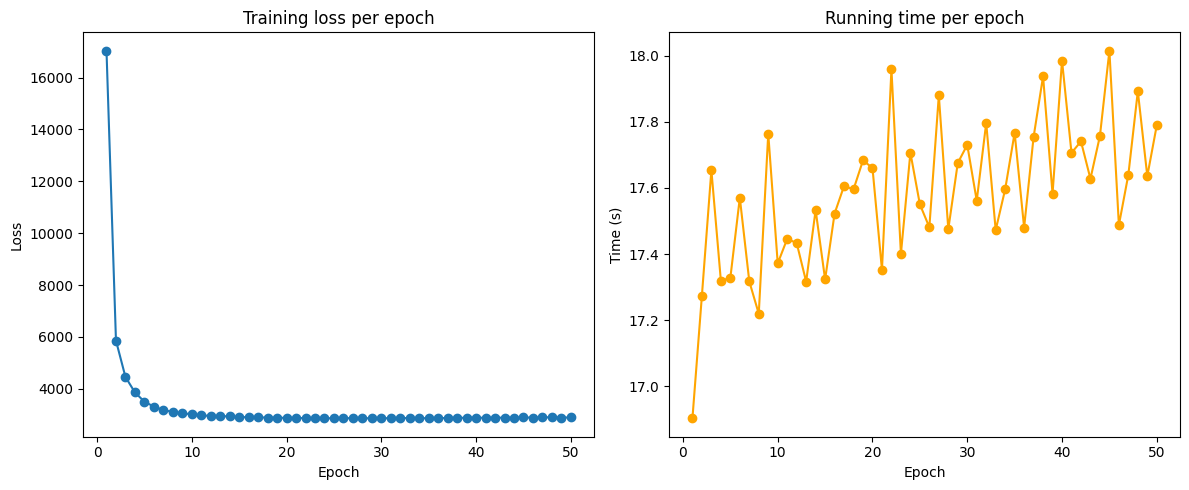

In [ ]:
# Plotting training loss and time
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), losses_epoch_train, marker='o')
plt.title("Training loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Time
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), epoch_times, marker='o', color='orange')
plt.title("Running time per epoch")
plt.xlabel("Epoch")
plt.ylabel("Time (s)")

plt.tight_layout()
plt.show()

3. Find 5 most likely nearby words of 10 extremely frequent words, as before.

In [ ]:
import torch

def get_predicted_context_words(model, word_indices, id2word, topn=5):
    model.eval()
    context_predictions = {}
    with torch.no_grad():
        for idx in word_indices:
            input_tensor = torch.tensor([idx])  # batch of size 1
            logits = model((input_tensor, input_tensor))  # context, target (target is used in forward)
            # logits shape: [1, vocab_size]
            top_indices = logits[0].topk(topn).indices.tolist()
            context_predictions[id2word[idx]] = [id2word[i] for i in top_indices]
    return context_predictions

# Convert words to indices
top_10_indices = [train_dataset.word2id[w] for w in top_10_most_frequent_words]

# Get predicted context words
predicted_contexts = get_predicted_context_words(skipgramModel, top_10_indices, train_dataset.id2word, topn=5)

# Display as table
import pandas as pd
df = pd.DataFrame([
    {"Target Word": k, "Top 5 nearby words": ", ".join(v)}
    for k, v in predicted_contexts.items()
])
df


,Target Word,Top 5 nearby words
0,de,"de, je, devant, comme, lon"
1,et,"et, donné, mon, monde, prisonnière"
2,la,"la, si, fois, luimême, sommes"
3,le,"le, est, effet, route, été"
4,que,"que, fit, entra, était, encore"
5,vous,"vous, par, un, ketty, regard"
6,je,"je, de, sire, vois, façon"
7,il,"il, dathos, chez, soir, être"
8,les,"les, une, est, autre, demain"
9,un,"un, vous, pas, petit, terrible"


# Some observations
- Hard to say if the output of my models are "correct" as I didn't read the book, even though I tried following the theory to the max.
- Nice drop in the epoch times and loss with another optimizer and when using negative smapling which is expected as we only updating a small subset of "negative" examples instead of the full output space.
- As I stated in my email, I find the loss quite high even the accuracy is acceptable, I didn't manage to catch the why.

